In [22]:
# Data presented in the paper [[zhang2024PerformanceInvestigation]]  
# plot them as references

import numpy as np

# 额外给定数据：BLC-max
BLC_max = np.array([
    [0, 298.16],
    [31.30, 299.30],
    [70.31, 300.34],
    [115.61, 301.12],
    [160.61, 301.74],
    [197.32, 302.22],
    [238.62, 302.60],
    [277.63, 302.88],
    [323.52, 303.12],
    [360.23, 303.27],
    [399.24, 303.39],
    [435.95, 303.47],
    [479.54, 303.50],
    [520.84, 303.51],
    [562.14, 303.52],
    [598.85, 303.53],
    [640.15, 303.54],
    [676.86, 303.55],
    [718.16, 303.56],
    [759.46, 303.58],
    [798.47, 303.63],
    [839.77, 303.72],
    [874.19, 303.86],
    [917.78, 304.08],
    [959.08, 304.39],
    [1002.68, 304.83],
    [1039.39, 305.43],
    [1076.10, 306.18],
    [1119.69, 307.10],
    [1158.70, 308.22],
    [1197.71, 309.47],
], dtype=float)
# 额外给定数据：BLC-min
BLC_min = np.array([
    [0, 298.16],
    [39.76, 298.42],
    [81.92, 298.62],
    [121.98, 298.76],
    [157.81, 298.86],
    [197.87, 298.93],
    [240.04, 299.00],
    [286.44, 299.05],
    [320.18, 299.07],
    [358.14, 299.09],
    [402.42, 299.11],
    [438.28, 299.13],
    [478.34, 299.14],
    [520.52, 299.14],
    [558.49, 299.15],
    [604.89, 299.16],
    [649.17, 299.17],
    [678.70, 299.17],
    [720.87, 299.19],
    [763.05, 299.20],
    [798.91, 299.22],
    [843.19, 299.26],
    [883.26, 299.30],
    [923.32, 299.35],
    [961.27, 299.42],
    [995.01, 299.50],
    [1041.39, 299.63],
    [1079.34, 299.78],
    [1121.50, 299.99],
    [1161.54, 300.24],
    [1200, 300.56],
], dtype=float)





In [23]:
from pathlib import Path
import re
import pandas as pd

def read_out_temperature(filename, series_name, data_dir=CFD_DATA_DIR):
    """
    读取本地文件夹中的 .out 文件。
    文件应至少包含两列数值：时间/步数 和 温度值。
    支持空格、Tab、逗号分隔；自动跳过表头和注释行。

    对 Fluent report .out 文件，常见格式为：
        Time Step, report-def, flow-time
    本函数默认取第 1 个数值为横坐标、第 2 个数值为温度。
    """
    path = Path(data_dir) / filename
    if not path.exists():
        raise FileNotFoundError(
            f"未找到 {path}。请确认 {filename} 和这个 notebook/program 放在同一个文件夹，"
            "或手动修改 CFD_DATA_DIR。"
        )

    rows = []
    with path.open("r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith(("#", "//")):
                continue

            # 提取每一行中的数值，兼容 scientific notation。
            nums = re.findall(r"[-+]?(?:\d+\.\d*|\.\d+|\d+)(?:[eE][-+]?\d+)?", line)
            if len(nums) >= 2:
                rows.append([float(nums[0]), float(nums[1])])

    if not rows:
        raise ValueError(f"{path} 中没有读到有效的两列数值数据：time 和 temperature。")

    data = pd.DataFrame(rows, columns=["time_s", "temperature"])
    # Check the values are within the expected range for temperature (e.g., 0-100 °C)
    
    data["temperature"] = data["temperature"] - 273.15  # 转换为摄氏度
    
    if not ((10 <= data["temperature"]).all() and (data["temperature"] <= 100).all()):
        print(f"WARNING: {series_name} is ignored since contains temperature values outside the expected range 10-100 °C. ")
        print(f"Values: min={data['temperature'].min():.2f}, max={data['temperature'].max():.2f}")
        return None    
    
    data.name = series_name
    return data[["time_s", "temperature"]]


def try_read_out_temperature(filename, series_name, data_dir=CFD_DATA_DIR):
    """读取 CFD .out 文件；如果文件不存在则跳过，避免只缺少某一组数据时整段绘图失败。"""
    try:
        data = read_out_temperature(filename, series_name, data_dir=data_dir)
        
        if data is None:
            print(f"WARNING: {series_name} contains no valid data and is ignored.")
            return None
        
        print(f"Loaded {series_name}: {Path(data_dir) / filename}, rows={len(data)}")
        return data
    
    except Exception as exc:
        print(f"WARNING: {exc}")
        return None

In [33]:
# load saved calculation results
import os
import sys

PROJECT_ROOT = os.path.abspath("../..")
CASE_ID = "C0017"
CASE_NAME = "C0017R00_ZHANG24_LC_THERM_1D_VAL"

N_bat_seg = 15
N_cool_seg = 20

# load the data frame

file_name = os.path.join(PROJECT_ROOT, "data", CASE_ID, CASE_NAME + ".xlsx")

import pandas as pd
df = pd.read_excel(file_name)

# load the battery temperature and the coolant temperature

T_bat_history = []

for i in range(N_bat_seg):
    T_bat_history.append(df[f"T_Segment_{i+1}"].values[1:])

T_cool_history = []
for i in range(N_cool_seg):
    T_cool_history.append(df[f"T_cool_{i+1}"].values[1:])

In [34]:
# Data sent by Liu, who find the maximum and minimum temperatures for liquid-cooled BTMS.

CFD_DATA_DIR = os.path.join(PROJECT_ROOT, "data","HP02E030112A1  result_T profile_liquid cooling_CFD_min, max, avg_min, avg_max")

print(f"CFD 数据读取目录: {CFD_DATA_DIR}")

# 要读取并绘制的 CFD 数据文件。
# 新增的两组数据为 min_avg.out 和 max_avg.out，图例分别为 CFD_min_avg 和 CFD_max_avg。
CFD_SERIES_FILES = {
    "CFD_max": "max.out",
    "CFD_min": "min.out",   
    "CFD_max_avg": "max_avg.out",
    "CFD_min_avg": "min_avg.out",
}

# 读取本地 CFD 数据。
cfd_series = []
for label, filename in CFD_SERIES_FILES.items():
    data = try_read_out_temperature(filename, label) 
    if data is not None:
        cfd_series.append((label, data))

CFD 数据读取目录: d:\Workspace\eBATS\data\HP02E030112A1  result_T profile_liquid cooling_CFD_min, max, avg_min, avg_max
Loaded CFD_max: d:\Workspace\eBATS\data\HP02E030112A1  result_T profile_liquid cooling_CFD_min, max, avg_min, avg_max\max.out, rows=1201
Loaded CFD_min: d:\Workspace\eBATS\data\HP02E030112A1  result_T profile_liquid cooling_CFD_min, max, avg_min, avg_max\min.out, rows=1201
Loaded CFD_max_avg: d:\Workspace\eBATS\data\HP02E030112A1  result_T profile_liquid cooling_CFD_min, max, avg_min, avg_max\max_avg.out, rows=1201
Loaded CFD_min_avg: d:\Workspace\eBATS\data\HP02E030112A1  result_T profile_liquid cooling_CFD_min, max, avg_min, avg_max\min_avg.out, rows=1201


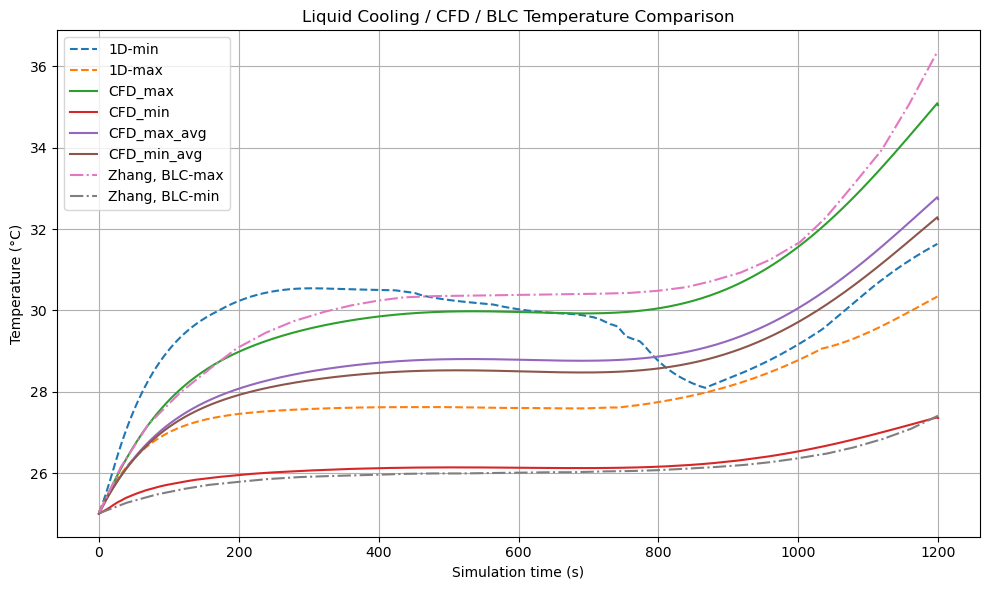

Loaded CFD series: CFD_max rows=1201, CFD_min rows=1201, CFD_max_avg rows=1201, CFD_min_avg rows=1201


In [35]:

import matplotlib.pyplot as plt
import numpy as np

num_time_steps = 1200
dt = 1

time_s = np.arange(num_time_steps) * dt

# Tmax_1D = np.array([max(T_bat_history[i]) for i in range(num_time_steps)])  # 取每个时间步最后一个电池单元的温度作为 max
T9_1D = np.array(T_bat_history[9])

Tmin_1D = np.array(T_bat_history[5]) # Liu told me that the 10th battery cell typically has the minimum temperature
# Tmin_1D = np.array([min(T_bat_history[i]) for i in range(num_time_steps)])   # 取每个时间步第一个电池单元的温度作为 min
plt.figure(figsize=(10, 6))

# plt.plot(time_s, Tmax_1D, linestyle="--", label="1D-max")
plt.plot(time_s, Tmin_1D, linestyle="--", label="1D-min")
plt.plot(time_s, T9_1D, linestyle="--", label="1D-max")

# 绘制所有已成功读取的 CFD 数据，包括新增的 CFD_min_avg / CFD_max_avg。
for label, data in cfd_series:
    plt.plot(data["time_s"], data["temperature"], label=label)    

plt.plot(BLC_max[:, 0], BLC_max[:, 1]-273.15, linestyle='-.', label="Zhang, BLC-max")
plt.plot(BLC_min[:, 0], BLC_min[:, 1]-273.15, linestyle='-.', label="Zhang, BLC-min")

# plot battery temperature without cooling for reference
# plt.plot(time_s, T_bat_wo_cooling, linestyle=":", label="1D-wo-cooling")

# plot the battery temperature calculated from the 0D model for reference
# plt.plot(time_s[:-1], T_bat_history_0D[:-1], linestyle=":", label="0D")
# plt.plot(time_s[:-1], T_cool_history_0D[:-1], linestyle=":", label="0D-cool, out")

# set the range of the y-axis for temperature comparison
# plt.ylim(23, 60)

plt.xlabel("Simulation time (s)")
plt.ylabel("Temperature (°C)")
plt.title("Liquid Cooling / CFD / BLC Temperature Comparison")
plt.grid(True)
plt.legend()
plt.tight_layout()

# plot_path = os.path.join(output_dir, "plot_liquid_cfd_avg_comparison.png")
# plt.savefig(plot_path, dpi=600)
plt.show()

# print(f"Saved comparison plot to: {plot_path}")
if cfd_series:
    print("Loaded CFD series:", ", ".join([f"{label} rows={len(data)}" for label, data in cfd_series]))
else:
    print("WARNING: no CFD .out files were loaded. Please check CFD_DATA_DIR and CFD_SERIES_FILES.")
